# Linear Mixed Effects Models in R

## Overview

Linear mixed effects models (LMMs) extend linear regression to handle **non-independent observations** — data collected from subjects, sites, or units that are measured repeatedly, nested within groups, or otherwise structured. They partition variance into fixed effects (population-level relationships) and random effects (group-level deviations).

| Term | What It Estimates |
|---|---|
| **Fixed effects** | Average relationship across the whole population — the coefficients you interpret and report |
| **Random intercepts** | How much each group's baseline differs from the population average |
| **Random slopes** | How much each group's response to a predictor differs from the population average |

> **When do you need a mixed model?**  
> When observations are not independent: repeated measures on the same subject, multiple measurements per site, students nested within schools, animals within enclosures. Using standard regression on clustered data produces underestimated standard errors and inflated type I error.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Invertebrate density measured at multiple time points per site (site as random effect); bird counts across multiple visits per transect; individual growth curves for tagged animals |
| **Healthcare** | Patient blood pressure measured at multiple clinic visits (patient as random effect); clinical trial with patients nested within hospitals |
| **Finance** | Monthly returns across multiple time periods per fund; customer spending across repeated transactions |
| **Insurance** | Annual claims per policyholder over multiple years; repeated property assessments per policy |

---

## Assumptions Checklist

- [ ] **Linearity:** Fixed effects relationships are linear
- [ ] **Normality of residuals:** Within-group residuals are approximately normally distributed
- [ ] **Normality of random effects:** Random effects are approximately normally distributed (check with caterpillar plots)
- [ ] **Homoscedasticity:** Residual variance is constant across groups and fitted values
- [ ] **Independence of residuals:** Residuals are independent after accounting for the random effects structure
- [ ] **Random effects structure is correctly specified:** Grouping structure matches the data — compare with likelihood ratio tests

> Full diagnostic workflow using DHARMa simulation-based residuals: see `dharma_diagnostics.ipynb`

---

## Setup

In [5]:
library(tidyverse)
library(ggplot2)
library(lme4)         # lmer() — core LMM fitting
library(lmerTest)     # adds p-values via Satterthwaite approximation
library(broom.mixed)  # tidy() for mixed model output
library(performance)  # r2() for marginal and conditional R²
library(DHARMa)       # simulation-based residual diagnostics
library(lattice)      # dotplot for random effects visualization

set.seed(42)

## Data

We use the built-in `sleepstudy` dataset (`lme4`): reaction time (ms) measured across 10 days of sleep deprivation for 18 subjects. Each subject is measured repeatedly — a textbook repeated-measures design. This structure maps directly to repeated site visits in ecology, longitudinal patient data, or repeated annual assessments.

,Reaction,Days,Subject
,<dbl>,<dbl>,<fct>
1,249.5600,0,308
2,258.7047,1,308
3,250.8006,2,308
4,321.4398,3,308
5,356.8519,4,308
6,414.6901,5,308


Subjects: 18 | Days per subject: 10 | Total obs: 180


`geom_smooth()` using formula = 'y ~ x'


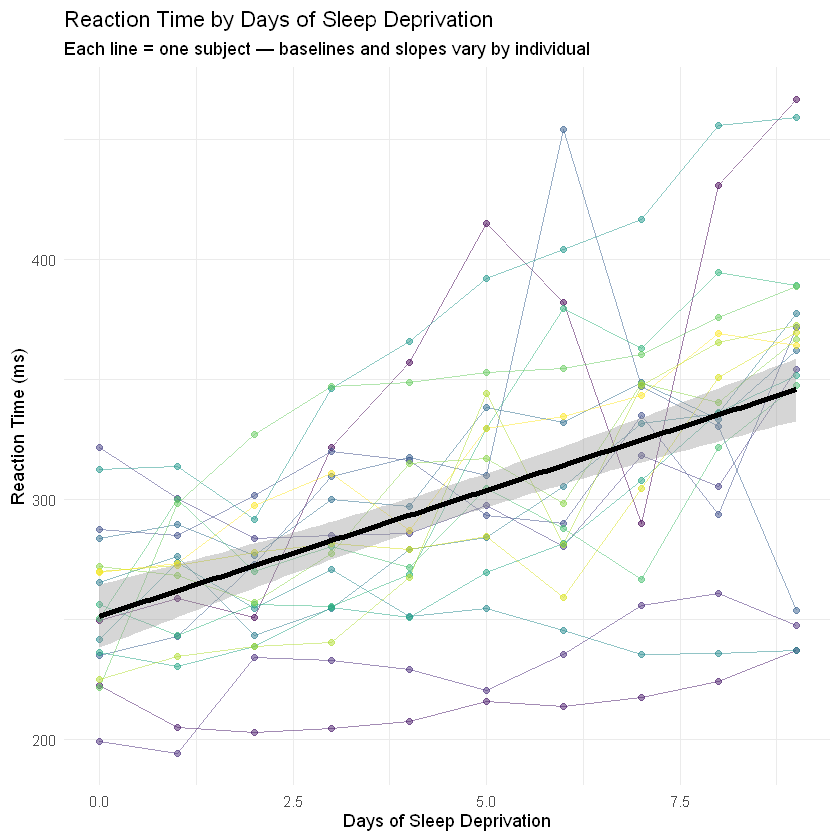

In [6]:
data(sleepstudy, package = "lme4")
head(sleepstudy)
cat(sprintf("Subjects: %d | Days per subject: %d | Total obs: %d\n",
            length(unique(sleepstudy$Subject)),
            length(unique(sleepstudy$Days)),
            nrow(sleepstudy)))

# ── Spaghetti plot: why we need a mixed model ─────────────────────────────────
ggplot(sleepstudy, aes(x = Days, y = Reaction,
                        group = Subject, color = Subject)) +
  geom_line(alpha = 0.5) +
  geom_point(alpha = 0.5, size = 1.5) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE,
              color = "black", linewidth = 1.5) +
  scale_color_viridis_d() +
  labs(title = "Reaction Time by Days of Sleep Deprivation",
       subtitle = "Each line = one subject — baselines and slopes vary by individual",
       x = "Days of Sleep Deprivation", y = "Reaction Time (ms)") +
  theme_minimal() +
  theme(legend.position = "none")
# Subjects start at different baselines → random intercepts needed
# Subjects deteriorate at different rates → random slopes likely needed

---

## Random Intercepts Model

Allows each subject to have their own baseline reaction time while estimating a single population-level slope for Days.

**lme4 formula:** `(1 | Subject)` = random intercept per subject

In [7]:
# ── Fit random intercepts model ───────────────────────────────────────────────
model_ri <- lmer(Reaction ~ Days + (1 | Subject),
                 data = sleepstudy,
                 REML = TRUE)   # REML = TRUE for variance estimates (default)
                                # REML = FALSE needed only for LRT model comparison
summary(model_ri)
# Fixed effects: population-level intercept and Days slope
# Random effects variance: between-subject variance + residual variance

# ── Tidy fixed effects with CIs ───────────────────────────────────────────────
broom.mixed::tidy(model_ri, effects = "fixed", conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Random effect deviations per subject ─────────────────────────────────────
# These are the subject-specific adjustments to the population intercept
ranef(model_ri)$Subject

# ── R² marginal and conditional ───────────────────────────────────────────────
performance::r2(model_ri)
# R²_marginal:    variance explained by fixed effects only
# R²_conditional: variance explained by fixed + random effects combined

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Reaction ~ Days + (1 | Subject)
   Data: sleepstudy

REML criterion at convergence: 1786.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2257 -0.5529  0.0109  0.5188  4.2506 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 1378.2   37.12   
 Residual              960.5   30.99   
Number of obs: 180, groups:  Subject, 18

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept) 251.4051     9.7467  22.8102   25.79   <2e-16 ***
Days         10.4673     0.8042 161.0000   13.02   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
     (Intr)
Days -0.371

effect,term,estimate,std.error,statistic,df,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),251.405,9.747,25.794,22.81,0,231.233,271.577
fixed,Days,10.467,0.804,13.015,161.00,0,8.879,12.055


,(Intercept)
,<dbl>
308,40.783710
309,-77.849554
310,-63.108567
330,4.406442
331,10.216189
332,8.221238
333,16.500494
334,-2.996981
335,-45.282127


# R2 for Mixed Models

  Conditional R2: 0.704
     Marginal R2: 0.280

---

## Random Intercepts + Random Slopes Model

Allows each subject to have their own baseline AND their own rate of change over time. This is the more flexible model — use it when the effect of a predictor plausibly varies across groups.

**lme4 formula:** `(Days | Subject)` = random intercept AND random slope for Days, correlated

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Reaction ~ Days + (Days | Subject)
   Data: sleepstudy

REML criterion at convergence: 1743.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9536 -0.4634  0.0231  0.4634  5.1793 

Random effects:
 Groups   Name        Variance Std.Dev. Corr 
 Subject  (Intercept) 612.10   24.741        
          Days         35.07    5.922   0.07 
 Residual             654.94   25.592        
Number of obs: 180, groups:  Subject, 18

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  251.405      6.825  17.000  36.838  < 2e-16 ***
Days          10.467      1.546  17.000   6.771 3.26e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
     (Intr)
Days -0.138

$Subject


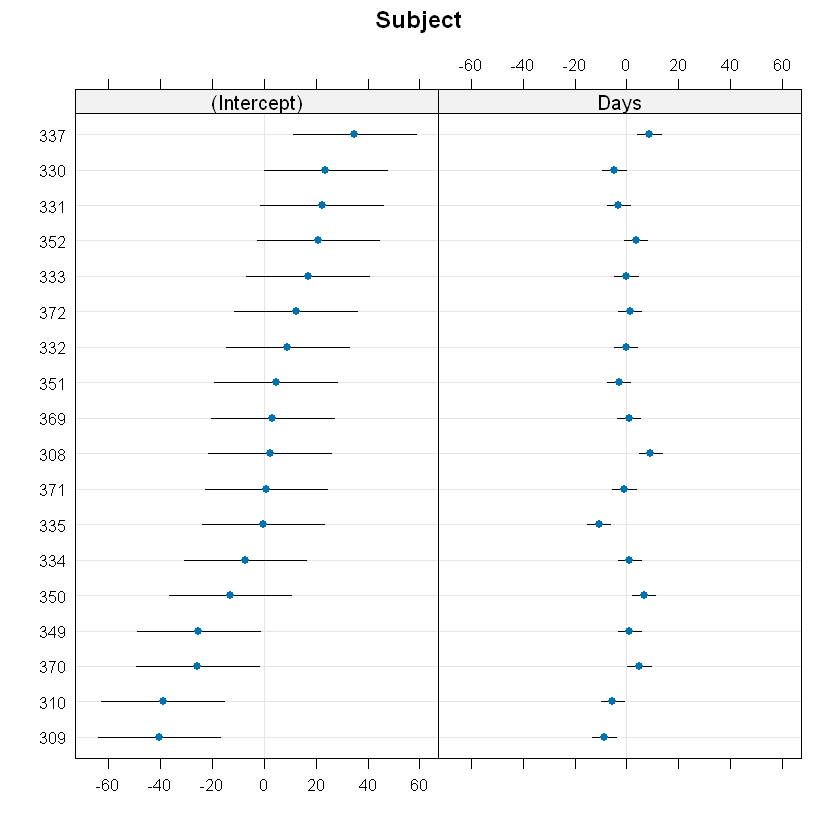

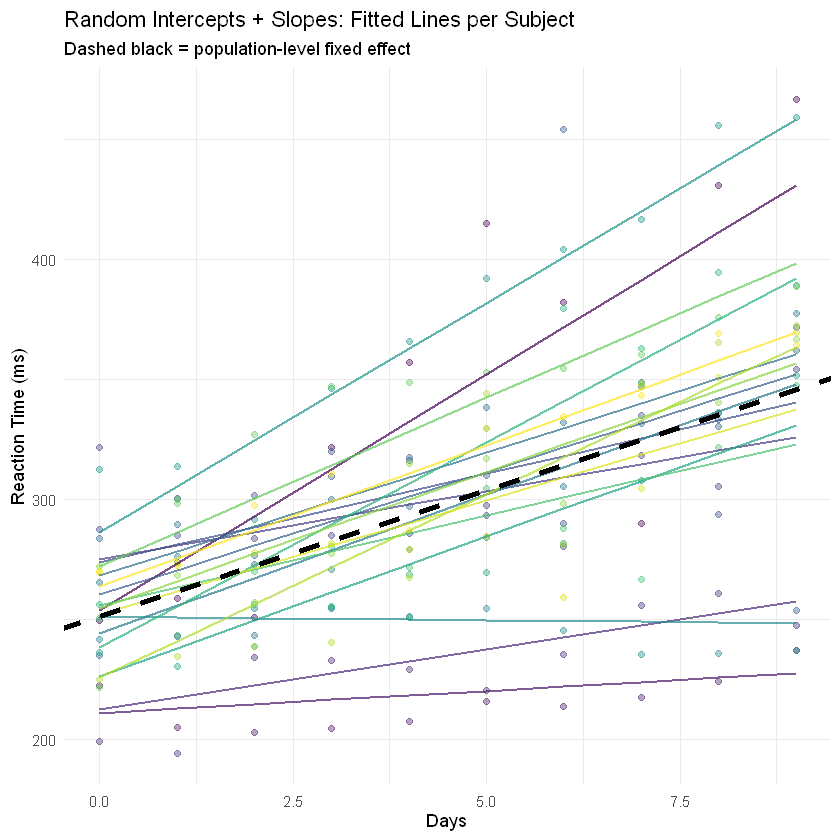

In [8]:
# ── Fit random slopes model ───────────────────────────────────────────────────
model_rs <- lmer(Reaction ~ Days + (Days | Subject),
                 data = sleepstudy,
                 REML = TRUE)
summary(model_rs)
# Random effects now shows:
#   Variance of random intercepts
#   Variance of random slopes
#   Correlation between them

# ── Uncorrelated random effects ───────────────────────────────────────────────
# Use || when correlation estimate is unstable or near ±1
model_rs_uncor <- lmer(Reaction ~ Days + (Days || Subject),
                        data = sleepstudy, REML = TRUE)

# ── Caterpillar plot: random effects estimates ────────────────────────────────
# Points = best linear unbiased predictions (BLUPs) for each subject
# Should be approximately normally distributed around 0
dotplot(ranef(model_rs, condVar = TRUE))

# ── Fitted lines per subject ──────────────────────────────────────────────────
sleepstudy$fitted_rs <- fitted(model_rs)

ggplot(sleepstudy, aes(x = Days, group = Subject, color = Subject)) +
  geom_point(aes(y = Reaction), alpha = 0.4, size = 1.5) +
  geom_line(aes(y = fitted_rs), linewidth = 0.8, alpha = 0.7) +
  geom_abline(intercept = fixef(model_rs)[1],
              slope     = fixef(model_rs)[2],
              linewidth = 1.5, color = "black", linetype = "dashed") +
  scale_color_viridis_d() +
  labs(title = "Random Intercepts + Slopes: Fitted Lines per Subject",
       subtitle = "Dashed black = population-level fixed effect",
       x = "Days", y = "Reaction Time (ms)") +
  theme_minimal() +
  theme(legend.position = "none")

---

## lme4 Formula Reference

| Formula | Structure |
|---|---|
| `(1 \| g)` | Random intercept only |
| `(x \| g)` | Random intercept + correlated random slope for x |
| `(x \|\| g)` | Random intercept + uncorrelated random slope for x |
| `(0 + x \| g)` | Random slope only (no random intercept) |
| `(1 \| g1) + (1 \| g2)` | Crossed random effects |
| `(1 \| g1/g2)` | Nested: g2 within g1 |

In [9]:
# ── Nested design: students within schools ────────────────────────────────────
nested_data <- tibble(
  school  = rep(paste0("S", 1:10), each = 20),
  ses     = rnorm(200),
  score   = 50 + 5*ses +
            rep(rnorm(10, 0, 8), each = 20) +
            rnorm(200, 0, 5)
)
model_nested <- lmer(score ~ ses + (1 | school), data = nested_data)
summary(model_nested)

# ── Crossed design: subjects × items ─────────────────────────────────────────
crossed_data <- expand_grid(
  subject   = paste0("subj", 1:20),
  item      = paste0("item", 1:10)
) %>%
  mutate(
    condition = sample(c(0L, 1L), n(), replace = TRUE),
    rt = 500 + 50*condition +
         rep(rnorm(20, 0, 40), each = 10) +
         rep(rnorm(10, 0, 20), times = 20) +
         rnorm(n(), 0, 30)
  )
model_crossed <- lmer(rt ~ condition + (1 | subject) + (1 | item),
                       data = crossed_data)
summary(model_crossed)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: score ~ ses + (1 | school)
   Data: nested_data

REML criterion at convergence: 1225.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.52099 -0.68139 -0.04079  0.67470  2.46736 

Random effects:
 Groups   Name        Variance Std.Dev.
 school   (Intercept) 99.19    9.960   
 Residual             22.10    4.701   
Number of obs: 200, groups:  school, 10

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)  47.2853     3.1670   9.0002   14.93 1.17e-07 ***
ses           5.1337     0.3471 189.1282   14.79  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
    (Intr)
ses 0.003 

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rt ~ condition + (1 | subject) + (1 | item)
   Data: crossed_data

REML criterion at convergence: 1984.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.43715 -0.66916 -0.01619  0.69810  2.12068 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 2857.5   53.46   
 item     (Intercept)  304.6   17.45   
 Residual              811.0   28.48   
Number of obs: 200, groups:  subject, 20; item, 10

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  503.074     13.490  26.086   37.29   <2e-16 ***
condition     54.006      4.468 173.674   12.09   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
          (Intr)
condition -0.159

---

## Reporting Results

In [10]:
# ── Fixed effects ─────────────────────────────────────────────────────────────
broom.mixed::tidy(model_rs, effects = "fixed", conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Variance components ───────────────────────────────────────────────────────
broom.mixed::tidy(model_rs, effects = "ran_pars") %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

performance::r2(model_rs)

# Standard reporting format:
# "Reaction time increased significantly with days of sleep deprivation
#  (β = X.XX ms/day, 95% CI [X.XX, X.XX], p < .001). A random intercepts
#  and slopes model accounted for repeated measures within subjects
#  (random intercept SD = XX.X ms; random slope SD = X.X ms/day;
#  intercept-slope correlation = .XX). The model explained XX% of total
#  variance (conditional R² = .XX; marginal R² = .XX)."

effect,term,estimate,std.error,statistic,df,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),251.405,6.825,36.838,17,0,237.006,265.804
fixed,Days,10.467,1.546,6.771,17,0,7.206,13.729


effect,group,term,estimate
<chr>,<chr>,<chr>,<dbl>
ran_pars,Subject,sd__(Intercept),24.741
ran_pars,Subject,sd__Days,5.922
ran_pars,Subject,cor__(Intercept).Days,0.066
ran_pars,Residual,sd__Observation,25.592


# R2 for Mixed Models

  Conditional R2: 0.799
     Marginal R2: 0.279

---

## Common Pitfalls

**1. Using repeated measures ANOVA instead of LMM**  
Repeated measures ANOVA cannot handle missing data, unbalanced designs, or continuous time. LMMs handle all of these naturally and are more flexible.

**2. Fitting random slopes without sufficient data**  
Random slopes require enough observations per group to reliably estimate group-level variance. Aim for at least 5-6 groups with 3-4+ observations per group per condition. Singular fit warnings often mean the random effects structure is too complex.

**3. Mixing up REML and ML**  
Use `REML = TRUE` for final models and variance component estimates. Use `REML = FALSE` when comparing models with different fixed effects via likelihood ratio tests.

**4. Singular fit warnings**  
A singular fit means one or more random effect variances are estimated at the boundary (zero or perfect correlation). Simplify the random effects structure — often by dropping the random slope or uncorrelating it with `||`.

**5. Reporting only marginal R²**  
Always report both marginal R² (fixed effects only) and conditional R² (fixed + random effects). They tell different stories about where explained variance comes from.

**6. Not checking random effects normality**  
Caterpillar plots should show approximately normally distributed BLUPs. Outlier groups or heavy tails suggest model misspecification or influential observations at the group level.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*